In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_excel("../data/final/final_data.xlsx")

In [10]:
df.head(5)

,order_id,order_date,first_class,order_day_name,on_truck_scan_date,on_truck_scan_day_name,order_to_truck_scan_days,ready_to_ship_date,pickup_date,processing_time,real_watting_time_ready_to_ship_until_leaving_facilities,estimate_delivery_date,estimate_shipping_time,estimate_total_order_time,real_arrival_date,real_whole_process
0,CA-2019-121755,2019-01-16,0,Wednesday,2019-01-23,Wednesday,7.0,NaT,NaT,NaN,NaN,2019-01-21,NaN,5,NaT,NaN
1,CA-2019-121755,2019-01-16,0,Wednesday,2019-01-23,Wednesday,7.0,NaT,NaT,NaN,NaN,2019-01-21,NaN,5,NaT,NaN
2,CA-2019-118255,2019-03-11,1,Monday,2019-03-13,Wednesday,2.0,NaT,NaT,NaN,NaN,2019-03-13,NaN,2,NaT,NaN
3,CA-2019-118255,2019-03-11,1,Monday,2019-03-13,Wednesday,2.0,NaT,NaT,NaN,NaN,2019-03-13,NaN,2,NaT,NaN
4,CA-2019-169194,2019-06-20,0,Thursday,2019-06-26,Wednesday,6.0,NaT,NaT,NaN,NaN,2019-06-24,NaN,4,NaT,NaN


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 16 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   order_id                                                  23171 non-null  str           
 1   order_date                                                23171 non-null  datetime64[us]
 2   first_class                                               23171 non-null  int64         
 3   order_day_name                                            23171 non-null  str           
 4   on_truck_scan_date                                        19076 non-null  datetime64[us]
 5   on_truck_scan_day_name                                    19076 non-null  str           
 6   order_to_truck_scan_days                                  19076 non-null  float64       
 7   ready_to_ship_date                                 

In [11]:
df.columns

Index(['order_id', 'order_date', 'first_class', 'order_day_name',
       'on_truck_scan_date', 'on_truck_scan_day_name',
       'order_to_truck_scan_days', 'ready_to_ship_date', 'pickup_date',
       'processing_time',
       'real_watting_time_ready_to_ship_until_leaving_facilities',
       'estimate_delivery_date', 'estimate_shipping_time',
       'estimate_total_order_time', 'real_arrival_date', 'real_whole_process'],
      dtype='str')

In [ ]:
df = df.rename(columns={
    'real_watting_time_ready_to_ship_until_leaving_facilities': 'waiting_time_ready_to_pickup'
})

#KPI: Total Delivery Time: Total Delivery Time = time from order placed → order delivered


This is the core business KPI because:

It directly reflects customer experience
It defines company 3-day delivery promise
It impacts retention, satisfaction, and cost

The mean: 10.8348
The median:  11.00

In [46]:
sla = (df["real_whole_process"] <= 3).mean()
sla

np.float64(0.0003992015968063872)

SLA: 0.0003992 ! 
this is very small! that means is very late!

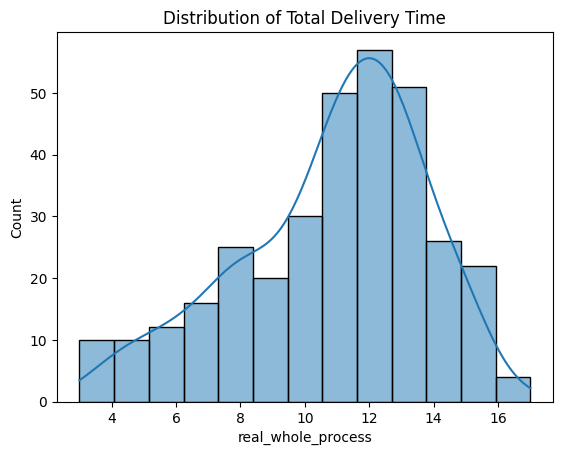

In [48]:
#Distribution (CRITICAL for insights)
sns.histplot(df_real["real_whole_process"], kde=True)
plt.title("Distribution of Total Delivery Time")
plt.show()

In [49]:
df["real_whole_process"].describe()

count    333.000000
mean      10.834835
std        2.862257
min        3.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       17.000000
Name: real_whole_process, dtype: float64

In [50]:
df_real["estimation_error"] = (
    df_real["real_whole_process"] - df_real["estimate_total_order_time"]
)

In [51]:
df_real["estimation_error"].mean()

np.float64(7.156156156156156)

#Deliveries are arriving ~7 days later than expected !

In [52]:
df_real["estimation_error"].describe()

count    333.000000
mean       7.156156
std        2.449416
min        0.000000
25%        6.000000
50%        7.000000
75%       10.000000
max       14.000000
Name: estimation_error, dtype: float64

Task was destroyed but it is pending!
task: <Task pending name='Task-229' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/pooneh_nezam/Desktop/Internship/Projects-/The-logistics-company/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-230' coro=<Kernel.shell_main() running at /Users/pooneh_nezam/Desktop/Internship/Projects-/The-logistics-company/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/pooneh_nezam/Desktop/Internship/Projects-/The-logistics-company/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/pooneh_nezam/Desktop/Internship/Projects-/The-logistics-company/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/__init__.py:5: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from pandas.plotting._matplotlib.boxplot import (
Task was destroyed but it is pending!

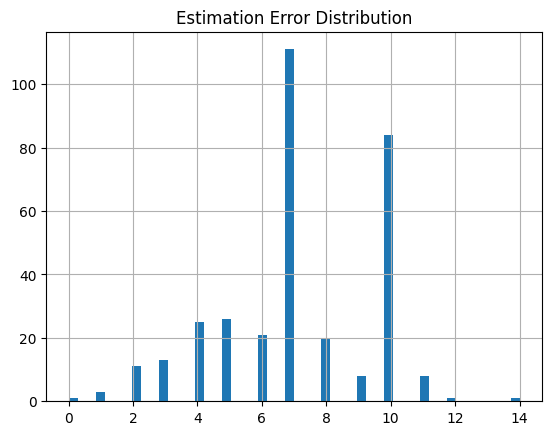

In [53]:
###distribution
df_real["estimation_error"].hist(bins=50)
plt.title("Estimation Error Distribution")
plt.show()

#“This KPI is based on partial data (~6.6% coverage), so results should be interpreted cautiously.”

In [54]:
sla = (df["real_whole_process"] <= 3).mean()

In [55]:
sla

np.float64(0.0003992015968063872)

"I calculated SLA compliance as the percentage of orders delivered within 3 days.
The result was only 0.04%, which indicates a severe mismatch between expected and actual delivery performance. 
This suggests major inefficiencies in the logistics pipeline."

In [56]:
df.groupby("first_class")["real_whole_process"].mean()

first_class
0    11.934109
1     7.053333
Name: real_whole_process, dtype: float64

"I compared delivery performance between standard and first-class shipments. While first-class orders are about 5 days faster on average, both categories significantly exceed the 3-day SLA target. This suggests that although prioritization improves speed, the overall logistics pipeline is inefficient and requires systemic optimization."

In [27]:
df_time_line = df[
    [
        # 🆔 ID
        'order_id',

        # 📅 Order info
        'order_date',
        'order_day_name',

        # 🚚 Warehouse / processing
        'on_truck_scan_date',
        'on_truck_scan_day_name',
        'ready_to_ship_date',
        'pickup_date',

        # 📦 Final delivery
        'real_arrival_date',

        # ⏱ Stage durations
        'order_to_truck_scan_days',
        'processing_time',
        'waiting_time_ready_to_pickup',

        # 📊 Estimates
        'estimate_delivery_date',
        'estimate_shipping_time',
        'estimate_total_order_time',

        # ⚙️ Flags
        'first_class'
    ]
]

In [57]:
#1. Processing time : 
df.groupby("first_class")["processing_time"].mean()

first_class
0    4.927152
1    2.037736
Name: processing_time, dtype: float64

In [62]:
#2. Waiting time (VERY IMPORTANT)
df.groupby("first_class")["waiting_time_ready_to_pickup"].mean()

first_class
0    1.986755
1    0.396226
Name: waiting_time_ready_to_pickup, dtype: float64

In [63]:
#3. Order → truck delay
df.groupby("first_class")["order_to_truck_scan_days"].mean()

first_class
0    7.091880
1    2.621418
Name: order_to_truck_scan_days, dtype: float64

Key Insights (VERY IMPORTANT)
1. MAIN BOTTLENECK = Order → Truck Delay

This is the biggest problem:

Standard: 7.09 days
First class: 2.62 days

This stage alone already:

Breaks the 3-day SLA
Explains your 7-day estimation error

 2. Processing is also too slow
Standard: ~5 days
First class: ~2 days

Even processing alone:

Already exceeds SLA (3 days) in standard

3. Waiting time confirms logistics issue
Standard: ~2 days waiting for pickup

This strongly suggests:

Truck schedule problem (not daily pickups)

Processing        ~4.93
Waiting           ~1.99
Truck delay       ~7.09
------------------------
Total ≈           14 days 

The main bottleneck in the delivery pipeline is the delay between order placement and truck dispatch, which averages over 7 days for standard orders. Additionally, warehouse processing times are also significantly high. While first-class shipments reduce delays across all stages, they still fail to meet the 3-day SLA. This indicates that the issue is structural, likely due to limited truck frequency and inefficient warehouse operations.

Actionable Recommendations (VERY IMPORTANT)
1. Increase pickup frequency (BIGGEST IMPACT)
Daily trucks instead of fixed days
Reduces waiting + truck delay
2. Improve warehouse processing
More staff / automation
Better prioritization
3. Smart prioritization
First_class is working → expand logic

SO: The majority of delivery time is spent before the order even leaves the warehouse.